In [ ]:
# installing modules
! pip install pandas numpy matplotlib seaborn scikit-learn


In [ ]:
#importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics

In [ ]:
import pandas as pd

# Path to the uploaded CSV file
file_path = "/content/drive/MyDrive/dataset_sdn.csv"  # Update the file path accordingly

# Read the CSV file from the local drive
df = pd.read_csv(file_path)

# Display the DataFrame
df


,dt,switch,src,dst,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,...,pktrate,Pairflow,Protocol,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
0,11425,1,10.0.0.1,10.0.0.8,45304,48294064,100,716000000,1.010000e+11,3,...,451,0,UDP,3,143928631,3917,0,0.0,0.0,0
1,11605,1,10.0.0.1,10.0.0.8,126395,134737070,280,734000000,2.810000e+11,2,...,451,0,UDP,4,3842,3520,0,0.0,0.0,0
2,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,1,3795,1242,0,0.0,0.0,0
3,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,2,3688,1492,0,0.0,0.0,0
4,11425,1,10.0.0.2,10.0.0.8,90333,96294978,200,744000000,2.010000e+11,3,...,451,0,UDP,3,3413,3665,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104340,5262,3,10.0.0.5,10.0.0.7,79,7742,81,842000000,8.184200e+10,5,...,0,0,ICMP,1,15209,12720,1,1.0,2.0,0
104341,5262,3,10.0.0.5,10.0.0.7,79,7742,81,842000000,8.184200e+10,5,...,0,0,ICMP,3,15099,14693,1,1.0,2.0,0
104342,5262,3,10.0.0.11,10.0.0.5,31,3038,31,805000000,3.180500e+10,5,...,1,0,ICMP,2,3409,3731,0,0.0,0.0,0
104343,5262,3,10.0.0.11,10.0.0.5,31,3038,31,805000000,3.180500e+10,5,...,1,0,ICMP,1,15209,12720,1,1.0,2.0,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


preprocessing

In [ ]:
# Information about data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104345 entries, 0 to 104344
Data columns (total 23 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   dt           104345 non-null  int64  
 1   switch       104345 non-null  int64  
 2   src          104345 non-null  object 
 3   dst          104345 non-null  object 
 4   pktcount     104345 non-null  int64  
 5   bytecount    104345 non-null  int64  
 6   dur          104345 non-null  int64  
 7   dur_nsec     104345 non-null  int64  
 8   tot_dur      104345 non-null  float64
 9   flows        104345 non-null  int64  
 10  packetins    104345 non-null  int64  
 11  pktperflow   104345 non-null  int64  
 12  byteperflow  104345 non-null  int64  
 13  pktrate      104345 non-null  int64  
 14  Pairflow     104345 non-null  int64  
 15  Protocol     104345 non-null  object 
 16  port_no      104345 non-null  int64  
 17  tx_bytes     104345 non-null  int64  
 18  rx_bytes     104345 non-

In [ ]:
df.describe()

,dt,switch,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,packetins,pktperflow,byteperflow,pktrate,Pairflow,port_no,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
count,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,1.043450e+05,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,104345.000000,104345.000000,104345.000000,1.043450e+05,1.043450e+05,104345.000000,103839.000000,103839.000000,104345.000000
mean,17927.514169,4.214260,52860.954746,3.818660e+07,321.497398,4.613880e+08,3.218865e+11,5.654234,5200.383468,6381.715291,4.716150e+06,212.210676,0.600987,2.331094,9.325264e+07,9.328039e+07,998.899756,1003.811420,2007.578742,0.390857
std,11977.642655,1.956327,52023.241460,4.877748e+07,283.518232,2.770019e+08,2.834029e+11,2.950036,5257.001450,7404.777808,7.560116e+06,246.855123,0.489698,1.084333,1.519380e+08,1.330004e+08,2423.471618,2054.887034,3144.437173,0.487945
min,2488.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,2.000000,4.000000,-130933.000000,-1.464426e+08,-4365.000000,0.000000,1.000000,2.527000e+03,8.560000e+02,0.000000,0.000000,0.000000,0.000000
25%,7098.000000,3.000000,808.000000,7.957600e+04,127.000000,2.340000e+08,1.270000e+11,3.000000,1943.000000,29.000000,2.842000e+03,0.000000,0.000000,1.000000,4.743000e+03,3.539000e+03,0.000000,0.000000,0.000000,0.000000
50%,11905.000000,4.000000,42828.000000,6.471930e+06,251.000000,4.180000e+08,2.520000e+11,5.000000,3024.000000,8305.000000,5.521680e+05,276.000000,1.000000,2.000000,4.219610e+06,1.338339e+07,0.000000,0.000000,4.000000,0.000000
75%,29952.000000,5.000000,94796.000000,7.620354e+07,412.000000,7.030000e+08,4.130000e+11,7.000000,7462.000000,10017.000000,9.728112e+06,333.000000,1.000000,3.000000,1.356398e+08,1.439277e+08,251.000000,557.000000,3838.000000,1.000000
max,42935.000000,10.000000,260006.000000,1.471280e+08,1881.000000,9.990000e+08,1.880000e+12,17.000000,25224.000000,19190.000000,1.495387e+07,639.000000,1.000000,5.000000,1.269982e+09,9.905962e+08,20580.000000,16577.000000,20580.000000,1.000000


In [ ]:
# column names
column_names= df.columns
column_names

Index(['dt', 'switch', 'src', 'dst', 'pktcount', 'bytecount', 'dur',
       'dur_nsec', 'tot_dur', 'flows', 'packetins', 'pktperflow',
       'byteperflow', 'pktrate', 'Pairflow', 'Protocol', 'port_no', 'tx_bytes',
       'rx_bytes', 'tx_kbps', 'rx_kbps', 'tot_kbps', 'label'],
      dtype='object')

Text(0, 0.5, 'Count')

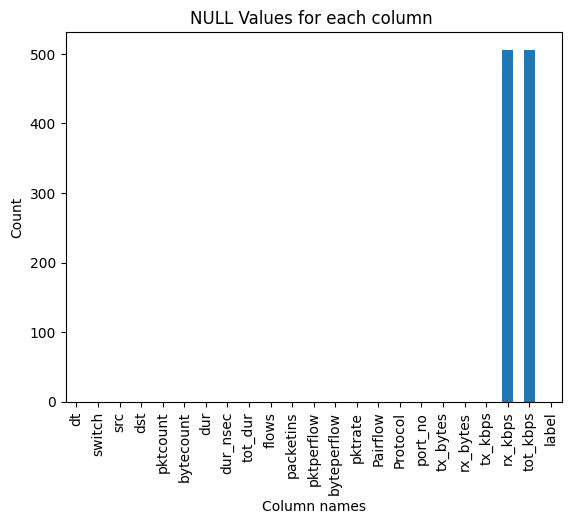

In [ ]:
# Null values sum
df.isnull().sum().plot.bar()
plt.title("NULL Values for each column ")
plt.xlabel("Column names")
plt.ylabel("Count")

In [ ]:
# Dropping rows having null values
df=df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103839 entries, 0 to 104344
Data columns (total 23 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   dt           103839 non-null  int64  
 1   switch       103839 non-null  int64  
 2   src          103839 non-null  object 
 3   dst          103839 non-null  object 
 4   pktcount     103839 non-null  int64  
 5   bytecount    103839 non-null  int64  
 6   dur          103839 non-null  int64  
 7   dur_nsec     103839 non-null  int64  
 8   tot_dur      103839 non-null  float64
 9   flows        103839 non-null  int64  
 10  packetins    103839 non-null  int64  
 11  pktperflow   103839 non-null  int64  
 12  byteperflow  103839 non-null  int64  
 13  pktrate      103839 non-null  int64  
 14  Pairflow     103839 non-null  int64  
 15  Protocol     103839 non-null  object 
 16  port_no      103839 non-null  int64  
 17  tx_bytes     103839 non-null  int64  
 18  rx_bytes     103839 non-null 

In [ ]:
# Getting unique destination
uniq_dest=df['dst'].unique()
total_dst=len(uniq_dest)
print("Total destination : ", total_dst)
print("Different destination : ",uniq_dest)

Total destination :  18
Different destination :  ['10.0.0.8' '10.0.0.7' '10.0.0.3' '10.0.0.5' '10.0.0.10' '10.0.0.13'
 '10.0.0.1' '10.0.0.11' '10.0.0.2' '10.0.0.4' '10.0.0.9' '10.0.0.6'
 '10.0.0.14' '10.0.0.15' '10.0.0.12' '10.0.0.16' '10.0.0.17' '10.0.0.18']


Text(0.5, 1.0, 'Traffic for normal and Malicious traffic')

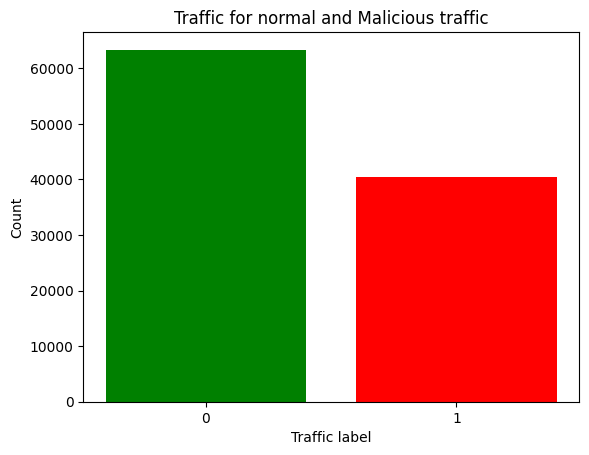

In [ ]:
# Doing analysis for malicious and normal traffic
gp=df.groupby('label')['label'].count()
plt.bar(list(gp.index),list(gp.values),color=['g','r'])
plt.xticks(list(gp.index))
plt.xlabel("Traffic label")
plt.ylabel("Count")
plt.title("Traffic for normal and Malicious traffic")

Text(0.5, 1.0, 'Attack and Normal traffic ')

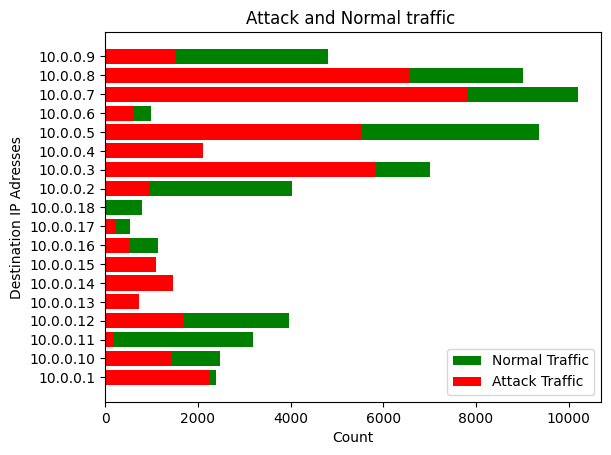

In [ ]:
ip_addr=df[df['label']==0].groupby('dst').count()['label'].index
normal_traffic=df.groupby(['dst','label']).size().unstack().fillna(0)[0]
attack_traffic=df.groupby(['dst','label']).size().unstack().fillna(0)[1]
plt.barh(ip_addr,normal_traffic,color='g', label='Normal Traffic')
plt.barh(ip_addr,attack_traffic,color='r', label='Attack Traffic')
plt.legend()
plt.xlabel("Count")
plt.ylabel("Destination IP Adresses")
plt.title("Attack and Normal traffic ")

In [ ]:
# Columns containing object(string) type data
# Port no column also does not do much so ignoring it also
object_col= list(df.select_dtypes(include=['object']).columns)
object_col=object_col+['port_no']
print(object_col)
data=df.drop(columns=object_col)

# seperating data based on protocol
udp_df = df[df['Protocol']=='UDP'].drop(columns=object_col)
tcp_df = df[df['Protocol']=='TCP'].drop(columns=object_col)
icmp_df = df[df['Protocol']=='ICMP'].drop(columns=object_col)
icmp_df

['src', 'dst', 'Protocol', 'port_no']


,dt,switch,pktcount,bytecount,dur,dur_nsec,tot_dur,flows,packetins,pktperflow,byteperflow,pktrate,Pairflow,tx_bytes,rx_bytes,tx_kbps,rx_kbps,tot_kbps,label
46116,26657,8,20,1960,21,201000000,2.120100e+10,3,10,0,0,0,1,5327,5327,0,0.0,0.0,0
46117,26657,8,20,1960,21,201000000,2.120100e+10,3,10,0,0,0,1,5457,3104,0,0.0,0.0,0
46118,26657,8,20,1960,21,201000000,2.120100e+10,3,10,0,0,0,1,3227,3185,0,0.0,0.0,0
46119,26657,8,20,1960,21,201000000,2.120100e+10,3,10,0,0,0,1,3357,1122,0,0.0,0.0,0
46120,26657,8,20,1960,21,43000000,2.104300e+10,3,10,0,0,0,1,5327,5327,0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104340,5262,3,79,7742,81,842000000,8.184200e+10,5,10,29,2842,0,0,15209,12720,1,1.0,2.0,0
104341,5262,3,79,7742,81,842000000,8.184200e+10,5,10,29,2842,0,0,15099,14693,1,1.0,2.0,0
104342,5262,3,31,3038,31,805000000,3.180500e+10,5,10,30,2940,1,0,3409,3731,0,0.0,0.0,0
104343,5262,3,31,3038,31,805000000,3.180500e+10,5,10,30,2940,1,0,15209,12720,1,1.0,2.0,0


Model building

In [ ]:
# importin modules for train test split
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture

GMM

UDP

In [ ]:
# splitting traing and testing data
udp_train,udp_test, udp_train_label, udp_test_label= train_test_split(udp_df[udp_df.columns[:-1]],udp_df['label'],test_size=0.3,random_state=42)

gmm= GaussianMixture(n_components=2)
gmm.fit(udp_train)
print("GMM Accuracy training data : ",metrics.accuracy_score(udp_train_label, gmm.predict(udp_train)))
print("GMM Accuracy testing data : ", metrics.accuracy_score(udp_test_label,gmm.predict(udp_test)))

GMM Accuracy training data :  0.9200673662391502
GMM Accuracy testing data :  0.9230226700251889


TCP

In [ ]:
# splitting traing and testing data
tcp_train,tcp_test, tcp_train_label, tcp_test_label= train_test_split(tcp_df[tcp_df.columns[:-1]],tcp_df['label'],test_size=0.3,random_state=42)

gmm= GaussianMixture(n_components=2)
gmm.fit(tcp_train)
print("GMM Accuracy training data : ",metrics.accuracy_score(tcp_train_label, gmm.predict(tcp_train)))
print("GMM Accuracy testing data : ", metrics.accuracy_score(tcp_test_label,gmm.predict(tcp_test)))

GMM Accuracy training data :  0.6127638922591604
GMM Accuracy testing data :  0.6083116294870343


ICMP

In [ ]:
# splitting traing and testing data
icmp_train,icmp_test, icmp_train_label, icmp_test_label= train_test_split(icmp_df[icmp_df.columns[:-1]],icmp_df['label'],test_size=0.3,random_state=42)

# GMM model

gmm= GaussianMixture(n_components=2)
gmm.fit(icmp_train)
print("GMM Accuracy training data : ",metrics.accuracy_score(icmp_train_label, gmm.predict(icmp_train)))
print("GMM Accuracy testing data : ", metrics.accuracy_score(icmp_test_label,gmm.predict(icmp_test)))

GMM Accuracy training data :  0.0725003457336468
GMM Accuracy testing data :  0.07880938936839559


Multi-Layer perceptron

UDP

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
clf= MLPClassifier(hidden_layer_sizes=(16,10),
                  random_state=5,
                  learning_rate_init=0.01)
clf.fit(udp_train,udp_train_label)
metrics.accuracy_score(clf.predict(udp_test), udp_test_label)

0.9414609571788413

TCP

In [ ]:
clf= MLPClassifier(hidden_layer_sizes=(18,12),
          random_state=5,
          learning_rate_init=0.01)
clf.fit(tcp_train,tcp_train_label)
print(metrics.accuracy_score(clf.predict(tcp_test), tcp_test_label))

0.6394519306986751


ICMP

In [ ]:
clf= MLPClassifier(hidden_layer_sizes=(16,10),
                  random_state=5,
                  learning_rate_init=0.01)
clf.fit(icmp_train,icmp_train_label)
metrics.accuracy_score(clf.predict(icmp_test), icmp_test_label)

0.999919335323062

KNN

UDP

In [ ]:
# Import necessary modules
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

In [ ]:
# Create feature and target arrays
X = udp_train
y = udp_train_label


knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X, y)

# Calculate the accuracy of the model
print(knn.score(udp_test, udp_test_label))

0.9621158690176322


TCP

In [ ]:
X = tcp_train
y = tcp_train_label


knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X, y)

# Calculate the accuracy of the model
print(knn.score(tcp_test, tcp_test_label))

0.7990035103612275


ICMP

In [ ]:
X = icmp_train
y = icmp_train_label


knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X, y)

# Calculate the accuracy of the model
print(knn.score(icmp_test, icmp_test_label))

0.9244978623860611


RANDOM FOREST


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score

UDP

In [ ]:
# create regressor object
udp_rf = RandomForestRegressor()

# fit the regressor with x and y data
udp_rf.fit(udp_train,udp_train_label)
predi = udp_rf.predict(udp_test)
accuracy_score(predi.round(), udp_test_label)

1.0

TCP

In [ ]:
# create regressor object
tcp_rf = RandomForestRegressor()

# fit the regressor with x and y data
tcp_rf.fit(tcp_train,tcp_train_label)
predi = tcp_rf.predict(tcp_test)
accuracy_score(predi.round(), tcp_test_label)

0.9996602876231457

ICMP

In [ ]:
# create regressor object
icmp_rf = RandomForestRegressor()

# fit the regressor with x and y data
icmp_rf.fit(icmp_train,icmp_train_label)
accuracy_score(icmp_rf.predict(icmp_test).round(), icmp_test_label)

1.0

RANDOM FOREST + ADABOOST

UDP

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from tabulate import tabulate

# Replace with your actual data (udp_train, udp_train_label, udp_test, udp_test_label)
# Example assumes you have already loaded and preprocessed your data

# Split data into training and test sets
X_train, X_test = udp_train, udp_test
y_train, y_test = udp_train_label, udp_test_label

# Create RandomForestClassifier object
rf_classifier = RandomForestClassifier()

# Fit the RandomForestClassifier with training data
rf_classifier.fit(X_train, y_train)

# Predict using RandomForestClassifier on test data
y_pred_rf = rf_classifier.predict(X_test)

# Calculate accuracy for RandomForestClassifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

# Create AdaBoostClassifier object using RandomForestClassifier as the base estimator
ada_classifier = AdaBoostClassifier(base_estimator=rf_classifier, n_estimators=50, learning_rate=1.0)

# Fit the AdaBoostClassifier with training data
ada_classifier.fit(X_train, y_train)

# Predict using AdaBoostClassifier on test data
y_pred_ada = ada_classifier.predict(X_test)

# Calculate accuracy for AdaBoostClassifier
accuracy_ada = accuracy_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada, average='weighted')
recall_ada = recall_score(y_test, y_pred_ada, average='weighted')
f1_ada = f1_score(y_test, y_pred_ada, average='weighted')

# Compile results into a table
results = [
    ["RandomForestClassifier", accuracy_rf, precision_rf, recall_rf, f1_rf],
    ["AdaBoostClassifier", accuracy_ada, precision_ada, recall_ada, f1_ada]
]

# Print results in tabular format
headers = ["Classifier", "Accuracy", "Precision", "Recall", "F1 Score"]
print(tabulate(results, headers=headers, tablefmt='grid'))


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


+------------------------+------------+-------------+----------+------------+
| Classifier             |   Accuracy |   Precision |   Recall |   F1 Score |
+========================+============+=============+==========+============+
| RandomForestClassifier |          1 |           1 |        1 |          1 |
+------------------------+------------+-------------+----------+------------+
| AdaBoostClassifier     |          1 |           1 |        1 |          1 |
+------------------------+------------+-------------+----------+------------+


Confusion Matrix for RandomForestClassifier:
[[4826    0]
 [   0 5099]]

Random Forest Classifier Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


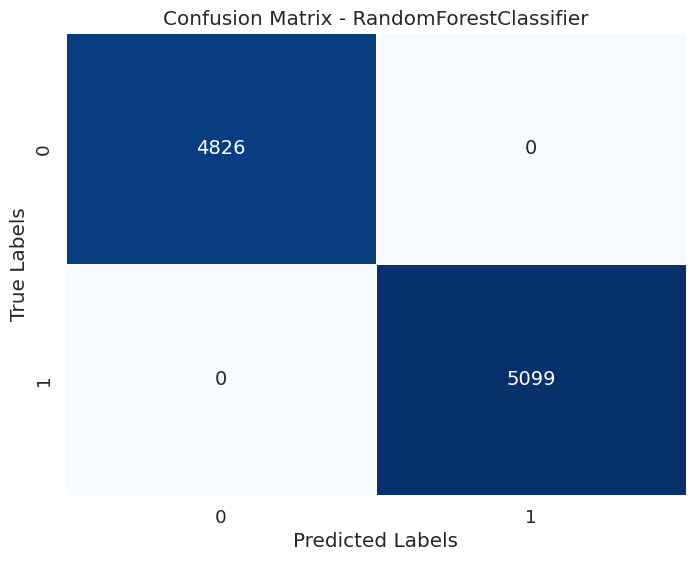

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(



Confusion Matrix for AdaBoostClassifier:
[[4826    0]
 [   0 5099]]

AdaBoost Classifier Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


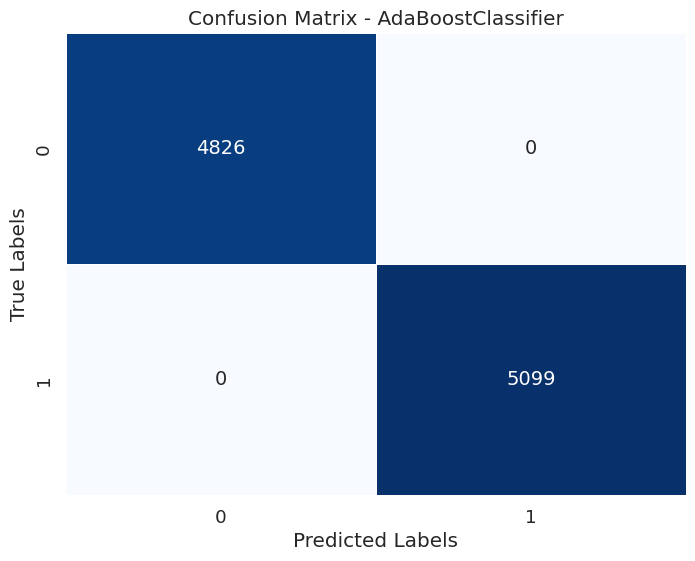

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Replace with your actual data (udp_train, udp_train_label, udp_test, udp_test_label)
# Example assumes you have already loaded and preprocessed your data

# Split data into training and test sets
X_train, X_test = udp_train, udp_test
y_train, y_test = udp_train_label, udp_test_label

# Create RandomForestClassifier object
rf_classifier = RandomForestClassifier()

# Fit the RandomForestClassifier with training data
rf_classifier.fit(X_train, y_train)

# Predict using RandomForestClassifier on test data
y_pred_rf = rf_classifier.predict(X_test)

# Calculate confusion matrix for RandomForestClassifier
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix for RandomForestClassifier:")
print(cm_rf)

# Calculate accuracy for RandomForestClassifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("\nRandom Forest Classifier Metrics:")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)

# Plotting confusion matrix for RandomForestClassifier
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'size': 14}, linewidths=0.5,
            xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - RandomForestClassifier')
plt.show()

# Create AdaBoostClassifier object using RandomForestClassifier as the base estimator
ada_classifier = AdaBoostClassifier(base_estimator=rf_classifier, n_estimators=50, learning_rate=1.0)

# Fit the AdaBoostClassifier with training data
ada_classifier.fit(X_train, y_train)

# Predict using AdaBoostClassifier on test data
y_pred_ada = ada_classifier.predict(X_test)

# Calculate confusion matrix for AdaBoostClassifier
cm_ada = confusion_matrix(y_test, y_pred_ada)
print("\nConfusion Matrix for AdaBoostClassifier:")
print(cm_ada)

# Calculate accuracy for AdaBoostClassifier
accuracy_ada = accuracy_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada, average='weighted')
recall_ada = recall_score(y_test, y_pred_ada, average='weighted')
f1_ada = f1_score(y_test, y_pred_ada, average='weighted')

print("\nAdaBoost Classifier Metrics:")
print("Accuracy:", accuracy_ada)
print("Precision:", precision_ada)
print("Recall:", recall_ada)
print("F1 Score:", f1_ada)

# Plotting confusion matrix for AdaBoostClassifier
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'size': 14}, linewidths=0.5,
            xticklabels=ada_classifier.classes_, yticklabels=ada_classifier.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - AdaBoostClassifier')
plt.show()


Text(0, 0.5, 'Importance ')

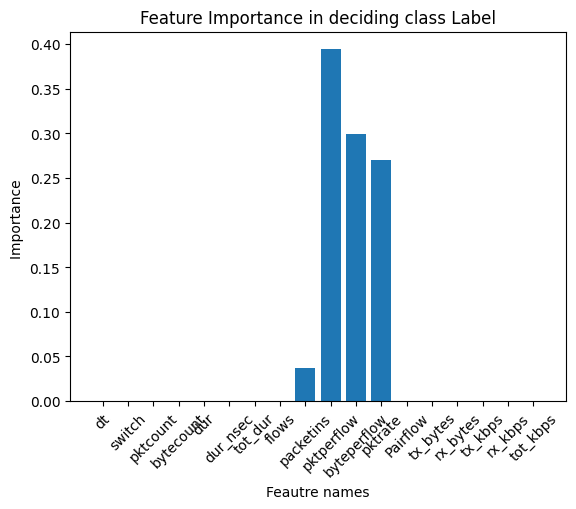

In [ ]:
#
plt.bar(udp_df.columns[:-1], udp_rf.feature_importances_)
plt.xticks(rotation=45)
plt.title("Feature Importance in deciding class Label")
plt.xlabel("Feautre names")
plt.ylabel("Importance ")

TCP

In [ ]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from tabulate import tabulate

# Replace with your actual data (udp_train, udp_train_label, udp_test, udp_test_label)
# Example assumes you have already loaded and preprocessed your data

# Split data into training and test sets
X_train, X_test = tcp_train, tcp_test
y_train, y_test = tcp_train_label, tcp_test_label

# Create RandomForestClassifier object
rf_classifier = RandomForestClassifier()

# Fit the RandomForestClassifier with training data
rf_classifier.fit(X_train, y_train)

# Predict using RandomForestClassifier on test data
y_pred_rf = rf_classifier.predict(X_test)

# Calculate accuracy for RandomForestClassifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

# Create AdaBoostClassifier object using RandomForestClassifier as the base estimator
ada_classifier = AdaBoostClassifier(base_estimator=rf_classifier, n_estimators=50, learning_rate=1.0)

# Fit the AdaBoostClassifier with training data
ada_classifier.fit(X_train, y_train)

# Predict using AdaBoostClassifier on test data
y_pred_ada = ada_classifier.predict(X_test)

# Calculate accuracy for AdaBoostClassifier
accuracy_ada = accuracy_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada, average='weighted')
recall_ada = recall_score(y_test, y_pred_ada, average='weighted')
f1_ada = f1_score(y_test, y_pred_ada, average='weighted')

# Compile results into a table
results = [
    ["AdaBoostClassifier", accuracy_rf, precision_rf, recall_rf, f1_rf],
    ["RandomForestClassifier", accuracy_ada, precision_ada, recall_ada, f1_ada]
]

# Print results in tabular format
headers = ["Classifier", "Accuracy", "Precision", "Recall", "F1 Score"]
print(tabulate(results, headers=headers, tablefmt='grid'))


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


+------------------------+------------+-------------+----------+------------+
| Classifier             |   Accuracy |   Precision |   Recall |   F1 Score |
+========================+============+=============+==========+============+
| AdaBoostClassifier     |   0.999887 |    0.999887 | 0.999887 |   0.999887 |
+------------------------+------------+-------------+----------+------------+
| RandomForestClassifier |   1        |    1        | 1        |   1        |
+------------------------+------------+-------------+----------+------------+


Confusion Matrix for RandomForestClassifier:
[[4738    0]
 [   0 4093]]

Random Forest Classifier Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


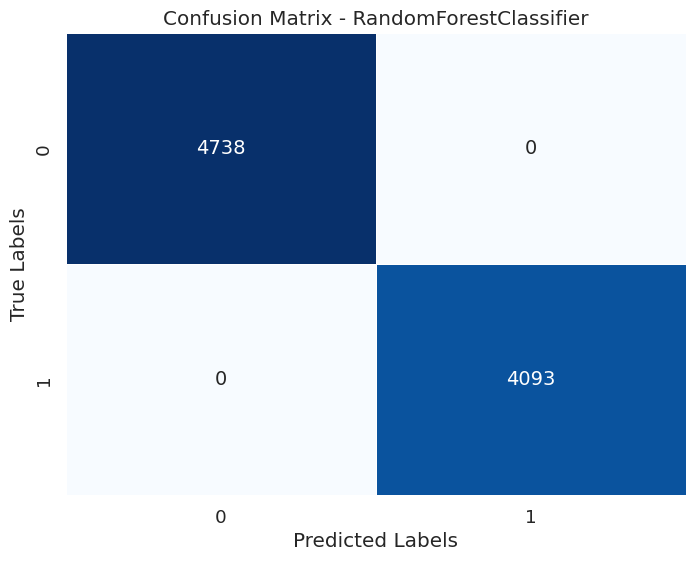

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(



Confusion Matrix for AdaBoostClassifier:
[[4738    0]
 [   0 4093]]

AdaBoost Classifier Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


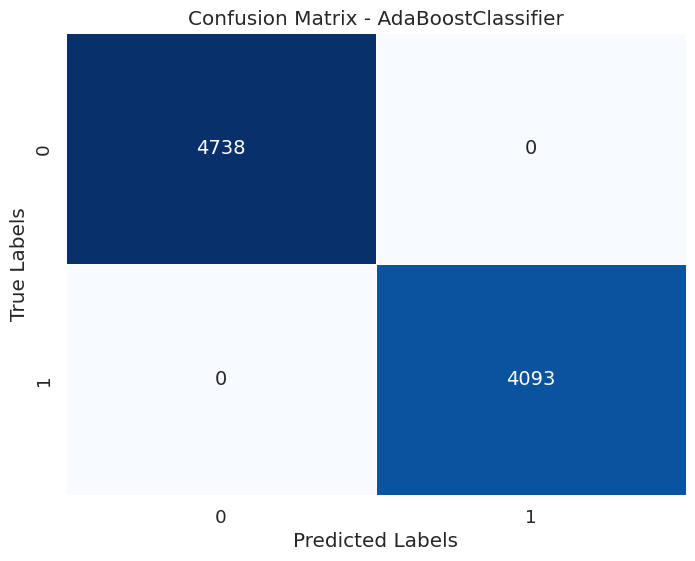

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Replace with your actual data (udp_train, udp_train_label, udp_test, udp_test_label)
# Example assumes you have already loaded and preprocessed your data

# Split data into training and test sets
X_train, X_test = tcp_train, tcp_test
y_train, y_test = tcp_train_label, tcp_test_label

# Create RandomForestClassifier object
rf_classifier = RandomForestClassifier()

# Fit the RandomForestClassifier with training data
rf_classifier.fit(X_train, y_train)

# Predict using RandomForestClassifier on test data
y_pred_rf = rf_classifier.predict(X_test)

# Calculate confusion matrix for RandomForestClassifier
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix for RandomForestClassifier:")
print(cm_rf)

# Calculate accuracy for RandomForestClassifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("\nRandom Forest Classifier Metrics:")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)

# Plotting confusion matrix for RandomForestClassifier
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'size': 14}, linewidths=0.5,
            xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - RandomForestClassifier')
plt.show()

# Create AdaBoostClassifier object using RandomForestClassifier as the base estimator
ada_classifier = AdaBoostClassifier(base_estimator=rf_classifier, n_estimators=50, learning_rate=1.0)

# Fit the AdaBoostClassifier with training data
ada_classifier.fit(X_train, y_train)

# Predict using AdaBoostClassifier on test data
y_pred_ada = ada_classifier.predict(X_test)

# Calculate confusion matrix for AdaBoostClassifier
cm_ada = confusion_matrix(y_test, y_pred_ada)
print("\nConfusion Matrix for AdaBoostClassifier:")
print(cm_ada)

# Calculate accuracy for AdaBoostClassifier
accuracy_ada = accuracy_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada, average='weighted')
recall_ada = recall_score(y_test, y_pred_ada, average='weighted')
f1_ada = f1_score(y_test, y_pred_ada, average='weighted')

print("\nAdaBoost Classifier Metrics:")
print("Accuracy:", accuracy_ada)
print("Precision:", precision_ada)
print("Recall:", recall_ada)
print("F1 Score:", f1_ada)

# Plotting confusion matrix for AdaBoostClassifier
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'size': 14}, linewidths=0.5,
            xticklabels=ada_classifier.classes_, yticklabels=ada_classifier.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - AdaBoostClassifier')
plt.show()


Text(0, 0.5, 'Importance ')

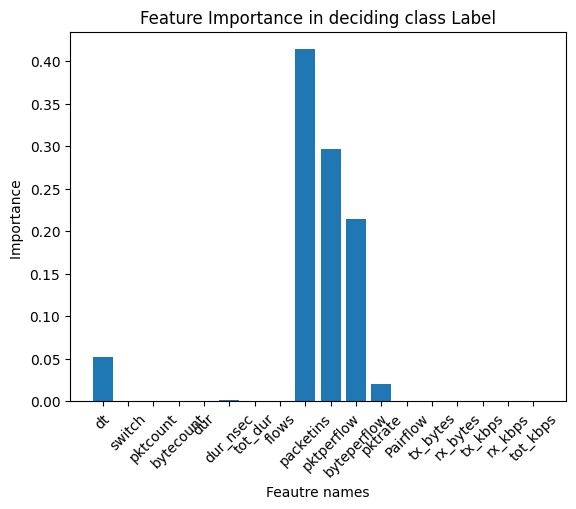

In [ ]:
plt.bar(tcp_df.columns[:-1], tcp_rf.feature_importances_)
plt.xticks(rotation=45)
plt.title("Feature Importance in deciding class Label")
plt.xlabel("Feautre names")
plt.ylabel("Importance ")

ICMP

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from tabulate import tabulate

# Replace with your actual data (udp_train, udp_train_label, udp_test, udp_test_label)
# Example assumes you have already loaded and preprocessed your data

# Split data into training and test sets
X_train, X_test = icmp_train, icmp_test
y_train, y_test = icmp_train_label, icmp_test_label

# Create RandomForestClassifier object
rf_classifier = RandomForestClassifier()

# Fit the RandomForestClassifier with training data
rf_classifier.fit(X_train, y_train)

# Predict using RandomForestClassifier on test data
y_pred_rf = rf_classifier.predict(X_test)

# Calculate accuracy for RandomForestClassifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

# Create AdaBoostClassifier object using RandomForestClassifier as the base estimator
ada_classifier = AdaBoostClassifier(base_estimator=rf_classifier, n_estimators=50, learning_rate=1.0)

# Fit the AdaBoostClassifier with training data
ada_classifier.fit(X_train, y_train)

# Predict using AdaBoostClassifier on test data
y_pred_ada = ada_classifier.predict(X_test)

# Calculate accuracy for AdaBoostClassifier
accuracy_ada = accuracy_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada, average='weighted')
recall_ada = recall_score(y_test, y_pred_ada, average='weighted')
f1_ada = f1_score(y_test, y_pred_ada, average='weighted')

# Compile results into a table
results = [
    ["AdaBoostClassifier", accuracy_rf, precision_rf, recall_rf, f1_rf],
    ["RandomForestClassifier", accuracy_ada, precision_ada, recall_ada, f1_ada]
]

# Print results in tabular format
headers = ["Classifier", "Accuracy", "Precision", "Recall", "F1 Score"]
print(tabulate(results, headers=headers, tablefmt='grid'))


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


+------------------------+------------+-------------+----------+------------+
| Classifier             |   Accuracy |   Precision |   Recall |   F1 Score |
+========================+============+=============+==========+============+
| AdaBoostClassifier     |          1 |           1 |        1 |          1 |
+------------------------+------------+-------------+----------+------------+
| RandomForestClassifier |          1 |           1 |        1 |          1 |
+------------------------+------------+-------------+----------+------------+


Confusion Matrix for RandomForestClassifier:
[[9564    0]
 [   0 2833]]

Random Forest Classifier Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


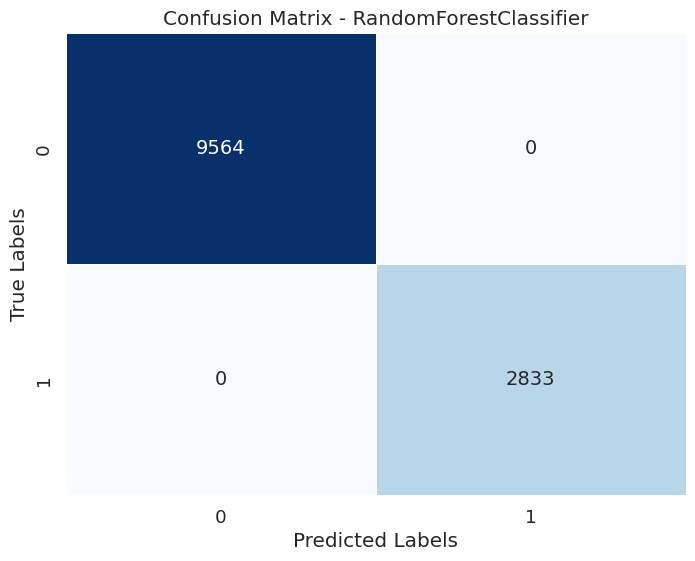

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(



Confusion Matrix for AdaBoostClassifier:
[[9564    0]
 [   0 2833]]

AdaBoost Classifier Metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


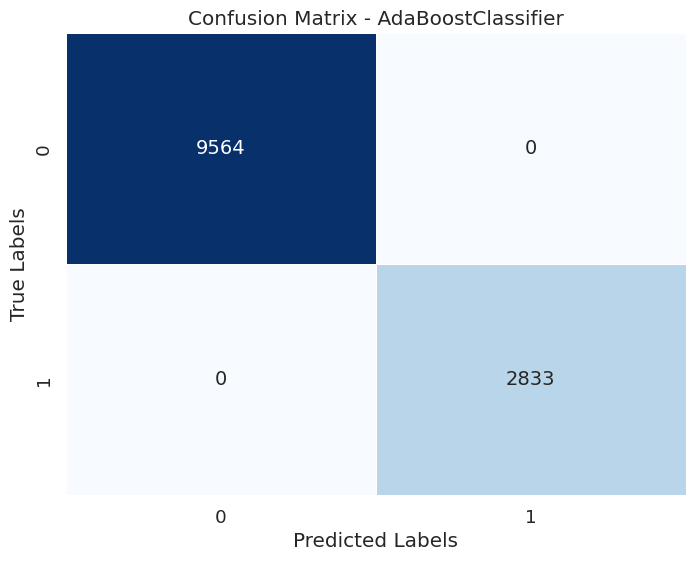

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Replace with your actual data (udp_train, udp_train_label, udp_test, udp_test_label)
# Example assumes you have already loaded and preprocessed your data

# Split data into training and test sets
X_train, X_test = icmp_train, icmp_test
y_train, y_test = icmp_train_label, icmp_test_label

# Create RandomForestClassifier object
rf_classifier = RandomForestClassifier()

# Fit the RandomForestClassifier with training data
rf_classifier.fit(X_train, y_train)

# Predict using RandomForestClassifier on test data
y_pred_rf = rf_classifier.predict(X_test)

# Calculate confusion matrix for RandomForestClassifier
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix for RandomForestClassifier:")
print(cm_rf)

# Calculate accuracy for RandomForestClassifier
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print("\nRandom Forest Classifier Metrics:")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 Score:", f1_rf)

# Plotting confusion matrix for RandomForestClassifier
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'size': 14}, linewidths=0.5,
            xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - RandomForestClassifier')
plt.show()

# Create AdaBoostClassifier object using RandomForestClassifier as the base estimator
ada_classifier = AdaBoostClassifier(base_estimator=rf_classifier, n_estimators=50, learning_rate=1.0)

# Fit the AdaBoostClassifier with training data
ada_classifier.fit(X_train, y_train)

# Predict using AdaBoostClassifier on test data
y_pred_ada = ada_classifier.predict(X_test)

# Calculate confusion matrix for AdaBoostClassifier
cm_ada = confusion_matrix(y_test, y_pred_ada)
print("\nConfusion Matrix for AdaBoostClassifier:")
print(cm_ada)

# Calculate accuracy for AdaBoostClassifier
accuracy_ada = accuracy_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada, average='weighted')
recall_ada = recall_score(y_test, y_pred_ada, average='weighted')
f1_ada = f1_score(y_test, y_pred_ada, average='weighted')

print("\nAdaBoost Classifier Metrics:")
print("Accuracy:", accuracy_ada)
print("Precision:", precision_ada)
print("Recall:", recall_ada)
print("F1 Score:", f1_ada)

# Plotting confusion matrix for AdaBoostClassifier
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={'size': 14}, linewidths=0.5,
            xticklabels=ada_classifier.classes_, yticklabels=ada_classifier.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - AdaBoostClassifier')
plt.show()


Text(0, 0.5, 'Importance ')

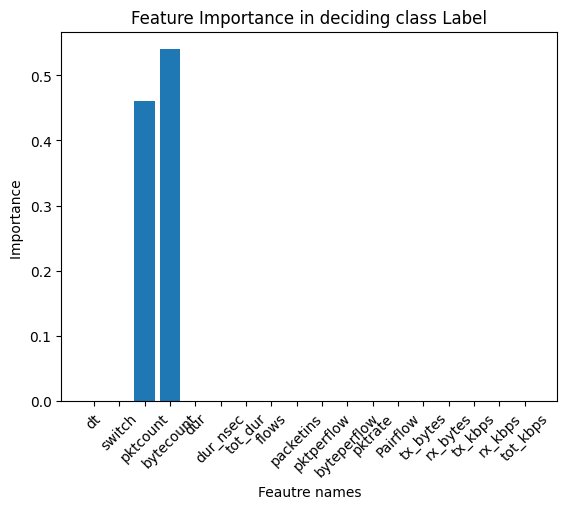

In [ ]:
plt.bar(icmp_df.columns[:-1], icmp_rf.feature_importances_)
plt.xticks(rotation=45)
plt.title("Feature Importance in deciding class Label")
plt.xlabel("Feautre names")
plt.ylabel("Importance ")

ACCURACY OF MODELS FOR UDP PROTOCOL

In [ ]:
import matplotlib.pyplot as plt

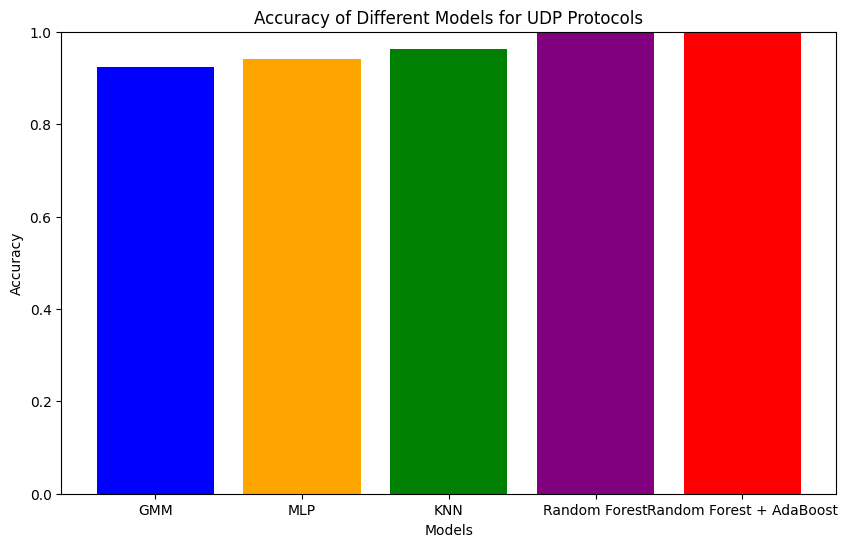

In [ ]:
# Define accuracy values

gmm_accuracy = 0.9230226700251889
mlp_accuracy = 0.9414609571788413
knn_accuracy = 0.9621158690176322
rf_adaboost_accuracy = 1.0

rf_accuracy_udp = 1.0  # Random Forest accuracy for UDP

# Define models and accuracies lists
models = ['GMM', 'MLP', 'KNN', 'Random Forest', 'Random Forest + AdaBoost']
accuracies = [gmm_accuracy, mlp_accuracy, knn_accuracy, rf_accuracy_udp, rf_adaboost_accuracy]

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['blue', 'orange', 'green', 'purple', 'red'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Models for UDP Protocols')
plt.ylim(0.0, 1.0)  # Set y-axis limits for better visualization
plt.show()



ACCURACY OF MODELS FOR TCP PROTOCOL

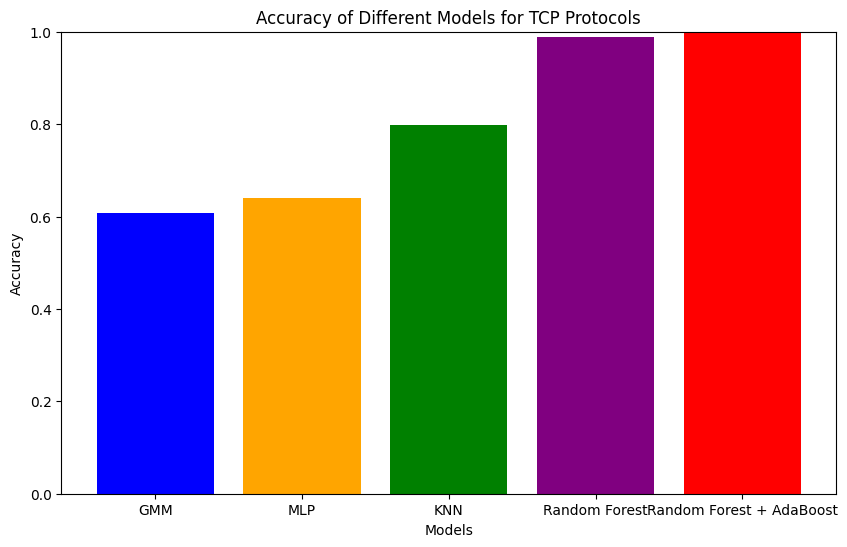

In [ ]:
# Define accuracy values
gmm_accuracy_tcp =  0.6084248669459857
mlp_accuracy_tcp = 0.6394519306986751
knn_accuracy_tcp = 0.7990035103612275
rf_accuracy_tcp = 0.98777  # Random Forest accuracy for TCP
rf_adaboost_accuracy_tcp =1.0

# Define models and accuracies lists
models_tcp = ['GMM', 'MLP', 'KNN', 'Random Forest', 'Random Forest + AdaBoost']
accuracies_tcp = [gmm_accuracy_tcp, mlp_accuracy_tcp, knn_accuracy_tcp, rf_accuracy_tcp, rf_adaboost_accuracy_tcp]

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models_tcp, accuracies_tcp, color=['blue', 'orange', 'green', 'purple', 'red'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Models for TCP Protocols')
plt.ylim(0.0, 1.0)  # Set y-axis limits for better visualization
plt.show()



ACCURACY OF MODELS FOR ICMP PROTOCOL

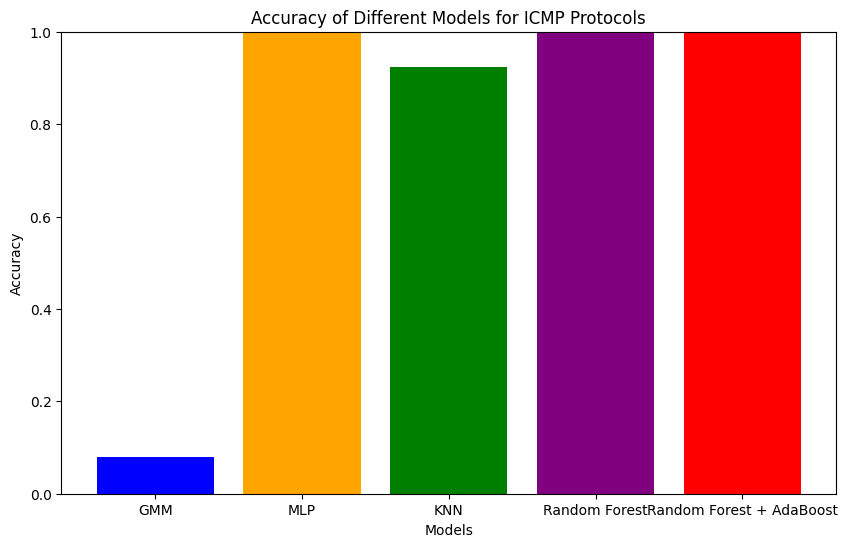

In [ ]:
# Define accuracy values
gmm_accuracy_icmp = 0.07880938936839559
mlp_accuracy_icmp = 0.999919335323062
knn_accuracy_icmp = 0.9244978623860611
rf_accuracy_icmp = 1.0  # Random Forest accuracy for ICMP

# Define Random Forest + AdaBoost accuracy for ICMP (same as Random Forest accuracy)
rf_adaboost_accuracy_icmp = rf_accuracy_icmp

# Define models and accuracies lists
models_icmp = ['GMM', 'MLP', 'KNN', 'Random Forest', 'Random Forest + AdaBoost']
accuracies_icmp = [gmm_accuracy_icmp, mlp_accuracy_icmp, knn_accuracy_icmp, rf_accuracy_icmp, rf_adaboost_accuracy_icmp]

# Plotting the bar chart
plt.figure(figsize=(10, 6))
plt.bar(models_icmp, accuracies_icmp, color=['blue', 'orange', 'green', 'purple', 'red'])
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Accuracy of Different Models for ICMP Protocols')
plt.ylim(0.0, 1.0)  # Set y-axis limits for better visualization
plt.show()


Accuracy table

In [ ]:
import pandas as pd
from tabulate import tabulate

# Data preparation (assuming you have the variables defined as in your previous code)
data = {
    'Algorithm': ['GMM', 'MLP', 'KNN','Random Forest','Random Forest+Adaboost',
                  'GMM', 'MLP', 'KNN','Random Forest','Random Forest+Adaboost',
                  'GMM', 'MLP', 'KNN','Random Forest','Random Forest+Adaboost'],
    'Protocol': ['UDP', 'UDP', 'UDP', 'UDP', 'UDP',
                 'TCP', 'TCP', 'TCP', 'TCP', 'TCP',
                 'ICMP', 'ICMP', 'ICMP', 'ICMP', 'ICMP'],
    'Testing Accuracy': [gmm_accuracy, mlp_accuracy, knn_accuracy, rf_accuracy_udp, rf_adaboost_accuracy,
                         gmm_accuracy_tcp, mlp_accuracy_tcp, knn_accuracy_tcp, rf_accuracy_tcp, rf_adaboost_accuracy_tcp,
                         gmm_accuracy_icmp, mlp_accuracy_icmp, knn_accuracy_icmp, rf_accuracy_icmp, rf_adaboost_accuracy_icmp]
}

# Create DataFrame
df = pd.DataFrame(data)

# Pivot the DataFrame
pivot_table = df.pivot(index='Algorithm', columns='Protocol', values='Testing Accuracy')

# Fill NaN values with 'N/A' for clarity
pivot_table = pivot_table.fillna('N/A')

# Find the maximum accuracy value
max_accuracy = pivot_table.max().max()

# Highlight all cells with the maximum accuracy value
for idx, row in pivot_table.iterrows():
    for col in pivot_table.columns:
        if pivot_table.at[idx, col] == max_accuracy:
            pivot_table.at[idx, col] = f"\033[92m{max_accuracy}\033[0m"  # Green color code

# Display the table using tabulate
print("Table with Testing Accuracy of Algorithms by Protocols:\n")
print(tabulate(pivot_table, headers='keys', tablefmt='grid'))


Table with Testing Accuracy of Algorithms by Protocols:

+------------------------+-----------+----------+----------+
| Algorithm              |      ICMP |      TCP |      UDP |
+========================+===========+==========+==========+
| GMM                    | 0.0788094 | 0.608425 | 0.923023 |
+------------------------+-----------+----------+----------+
| KNN                    | 0.924498  | 0.799004 | 0.962116 |
+------------------------+-----------+----------+----------+
| MLP                    | 0.999919  | 0.639452 | 0.941461 |
+------------------------+-----------+----------+----------+
| Random Forest          | 1         | 0.98777  | 1        |
+------------------------+-----------+----------+----------+
| Random Forest+Adaboost | 1         | 1        | 1        |
+------------------------+-----------+----------+----------+
